In [1]:
!pip install -q gdown
!gdown --fuzzy "https://drive.google.com/file/d/1GrJHVstisCglttDnZdtfc8_rTIeBiKnz/view?usp=sharing"

Downloading...
From (original): https://drive.google.com/uc?id=1GrJHVstisCglttDnZdtfc8_rTIeBiKnz
From (redirected): https://drive.google.com/uc?id=1GrJHVstisCglttDnZdtfc8_rTIeBiKnz&confirm=t&uuid=b0b65e84-c164-429c-9755-dabcfa2691d6
To: /content/archive.zip
100% 2.46G/2.46G [00:38<00:00, 64.4MB/s]


In [2]:
import zipfile
import os

zip_path = '/content/archive.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done")
print(os.listdir(extract_path))

Extraction done
['chest_xray']


In [3]:
import os

data_dir = "/content/dataset/chest_xray"

print("Main folders:", os.listdir(data_dir))
print("Train classes:", os.listdir(os.path.join(data_dir, "train")))
print("Val classes:", os.listdir(os.path.join(data_dir, "val")))
print("Test classes:", os.listdir(os.path.join(data_dir, "test")))

Main folders: ['test', 'chest_xray', '__MACOSX', 'val', 'train']
Train classes: ['NORMAL', 'PNEUMONIA']
Val classes: ['NORMAL', 'PNEUMONIA']
Test classes: ['NORMAL', 'PNEUMONIA']


In [4]:
import os

# Consistent Path Naming
DATASET_DIR = '/content/dataset/chest_xray'
TRAIN_PATH = os.path.join(DATASET_DIR, 'train')
TEST_PATH = os.path.join(DATASET_DIR, 'test')

print(f"Data Directory: {DATASET_DIR}")

Data Directory: /content/dataset/chest_xray


In [5]:
import shutil

shutil.rmtree("/content/dataset/_MACOSX", ignore_errors=True)
print("Removed _MACOSX")

Removed _MACOSX


1. Snatching the Data from Kaggle & Setting up Drive

Instead of downloading the data to out local machine and wasting time uploading it back to Colab, i hosted it on Google Drive, mounted your Drive to Colab, and used a slick gdown command to pull the zip file in seconds and extract it right into colab

2. Cleaning the Data (The Post-Extraction Scrub)

deleting __MACOSX that always messes things up during training

In [6]:
shutil.rmtree("/content/dataset/chest_xray/_MACOSX", ignore_errors=True)

/tmp/ipykernel_734/1115469216.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=train_counts, palette='mako')


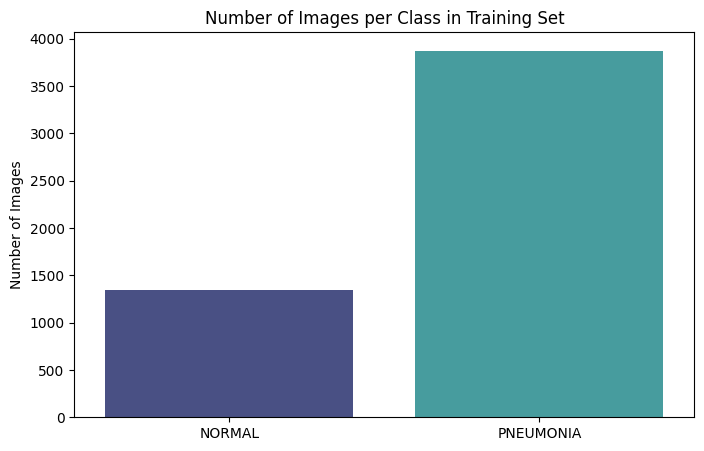

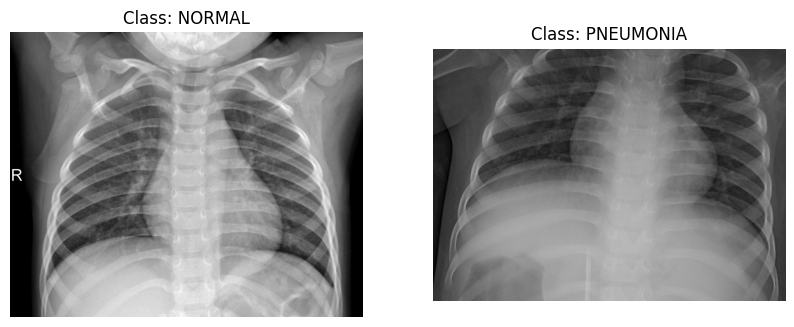

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np
import os

# Using consistent TRAIN_PATH
classes = ['NORMAL', 'PNEUMONIA']
train_counts = [len(os.listdir(os.path.join(TRAIN_PATH, c))) for c in classes]

plt.figure(figsize=(8, 5))
sns.barplot(x=classes, y=train_counts, palette='mako')
plt.title('Number of Images per Class in Training Set')
plt.ylabel('Number of Images')
plt.show()

plt.figure(figsize=(10, 5))
for i, c in enumerate(classes):
    folder_path = os.path.join(TRAIN_PATH, c)
    img_names = os.listdir(folder_path)
    if img_names:
        img_path = os.path.join(folder_path, img_names[0])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, 2, i+1)
        plt.imshow(img)
        plt.title(f"Class: {c}")
        plt.axis('off')
plt.show()

We visualized the data using Seaborn graphs to check the balance between 'Normal' and 'Pneumonia' images. Then, we plotted a few grayscale X-ray samples just to make sure everything was loaded correctly and looking sharp.

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Moderate augmentation, no horizontal_flip as requested
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Compute Class Weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class Weights: {class_weight_dict}")

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class Weights: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


To stop this model from just memorizing the images (overfitting), you brought in the ImageDataGenerator.we  applied some clever augmentations to the training data—like slight zooms and rotations. This forces the model to actually learn the visual features of the disease, not just memorize the exact pixels. For the validation and test sets, we kept it strictly to rescaling (1./255) so the evaluation remains fair.

In [10]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Build DenseNet121
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("DenseNet121 Model Architecture Ready")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet121 Model Architecture Ready


In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_densenet_model.keras', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.00001)
]

EPOCHS = 8

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.8483 - loss: 0.3444 - val_accuracy: 0.9223 - val_loss: 0.1934 - learning_rate: 0.0010
Epoch 2/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 123s 941ms/step - accuracy: 0.8902 - loss: 0.2682 - val_accuracy: 0.9089 - val_loss: 0.2137 - learning_rate: 0.0010
Epoch 3/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 122s 934ms/step - accuracy: 0.8831 - loss: 0.2677 - val_accuracy: 0.9175 - val_loss: 0.1960 - learning_rate: 0.0010
Epoch 4/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 124s 944ms/step - accuracy: 0.9137 - loss: 0.2226 - val_accuracy: 0.9204 - val_loss: 0.1818 - learning_rate: 2.0000e-04
Epoch 5/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 123s 937ms/step - accuracy: 0.9056 - loss: 0.2324 - val_accuracy: 0.9128 - val_loss: 0.2051 - learning_rate: 2.0000e-04
Epoch 6/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 928ms/step - accuracy: 0.9097 - loss: 0.2158 - val_accuracy: 0.9166 - val_loss: 0.1950 - learning_rate: 2.0000e-04
Epoch 7/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 123s 942ms/step - accu

5.DenseNet121 model

6.Training (Using Callbacks)
When it came to training :

EarlyStopping: To automatically stop the training if the model stops improving, saving you time and preventing overfitting.

ModelCheckpoint: To save the absolute best version of your model's weights so nothing gets lost.

ReduceLROnPlateau: To drop the learning rate if the model gets stuck, helping it catch those fine, complex details.

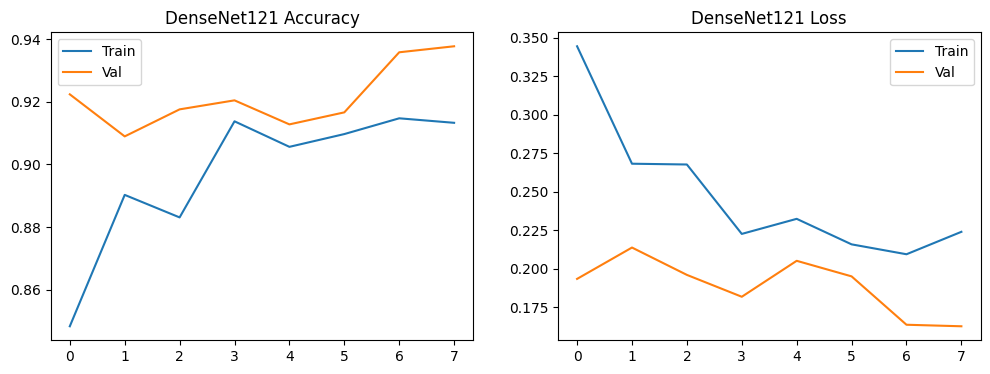

20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step

--- Classification Report ---
              precision    recall  f1-score   support

      NORMAL       0.87      0.79      0.83       234
   PNEUMONIA       0.88      0.93      0.90       390

    accuracy                           0.88       624
   macro avg       0.87      0.86      0.87       624
weighted avg       0.88      0.88      0.88       624


--- Confusion Matrix ---
[[185  49]
 [ 28 362]]

Test Accuracy: 0.8766
ROC-AUC Score: 0.9524


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import pandas as pd

# 1. Learning Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('DenseNet121 Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('DenseNet121 Loss')
plt.legend()
plt.show()

# 2. Detailed Evaluation
preds = model.predict(test_generator)
y_pred = (preds > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_true, y_pred))

print(f"\nTest Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_true, preds):.4f}")

we plotted the Accuracy and Loss graphs to see how the model learned across the epochs. Then came the moment of truth: evaluating the model on the unseen Test data to get the real-world accuracy score and make sure it actually performs well on new images.

In [13]:
# Export Predictions for Ensemble
results_df = pd.DataFrame({
    'filename': test_generator.filenames,
    'true_label': y_true,
    'pred_label': y_pred,
    'prob_pneumonia': preds.flatten()
})

results_df.to_csv('densenet_test_predictions.csv', index=False)
print("Predictions exported to densenet_test_predictions.csv")

Predictions exported to densenet_test_predictions.csv


finally , simple ui with gradio.